In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mbalvi/student_feedback_data/main/Student_Feedback.csv"

df = pd.read_csv(url,encoding="latin1")

df.head()

,comments,sentiments
0,TEACHERS HELP US IN CAREER BUILDING,1
1,Having no technical knowledge about their taug...,0
2,teacher should give us the practical knowledge...,2
3,better teaching methodology,1
4,best teaching method,1


In [ ]:
df["sentiments"].value_counts()

,count
sentiments,
1,551
0,436
2,99


In [ ]:
df.groupby("sentiments")["comments"].first()

,comments
sentiments,
0,Having no technical knowledge about their taug...
1,TEACHERS HELP US IN CAREER BUILDING
2,teacher should give us the practical knowledge...


In [ ]:
df.isnull().sum()

,0
comments,0
sentiments,0


In [ ]:
df.shape

(1086, 2)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    df["comments"],
    df["sentiments"],
    test_size=0.2,
    random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_valid))

Training: 868
Validation: 218


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from numpy import vectorize
vectorize=TfidfVectorizer()

In [ ]:
X_train_tfidf = vectorize.fit_transform(X_train)
X_valid_tfidf = vectorize.transform(X_valid)

In [ ]:
print(X_train_tfidf.shape)
print(X_valid_tfidf.shape)

(868, 1280)
(218, 1280)


In [26]:
from sklearn.linear_model import LogisticRegression

In [29]:
model= LogisticRegression(max_iter=1000,class_weight="balanced")

In [30]:
model.fit(X_train_tfidf,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
y_pred_balanced=model.predict(X_valid_tfidf)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred_balanced)

print("Accuracy:", accuracy)

Accuracy: 0.6972477064220184


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.73      0.70      0.72        91
           1       0.74      0.73      0.74       103
           2       0.45      0.54      0.49        24

    accuracy                           0.70       218
   macro avg       0.64      0.66      0.65       218
weighted avg       0.70      0.70      0.70       218



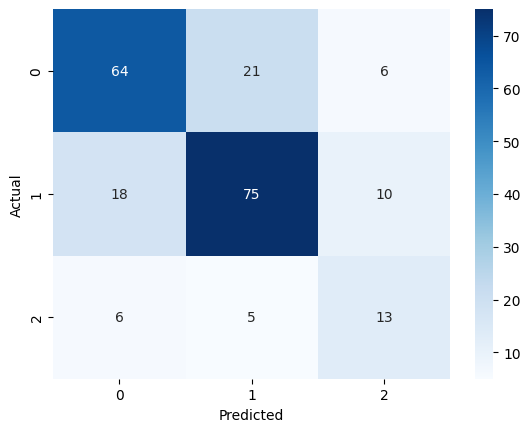

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred_balanced)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
new_comment = ["The teacher explains everything clearly and helps students."]

In [42]:
new_comment_tfidf = vectorize.transform(new_comment)

In [43]:
prediction = model.predict(new_comment_tfidf)

print("Prediction:", prediction)

Prediction: [1]


In [44]:
new_comments = [
    "The teacher is very helpful and explains well.",
    "The facilities are terrible and need improvement.",
    "The course is okay, nothing special."
]

In [49]:
new_comment_tfidf = vectorize.transform(new_comments)

In [50]:
predictions = model.predict(new_comment_tfidf)

print("Prediction:", predictions)

Prediction: [1 0 1]


In [53]:
df["sentiments"].value_counts()

,count
sentiments,
1,551
0,436
2,99


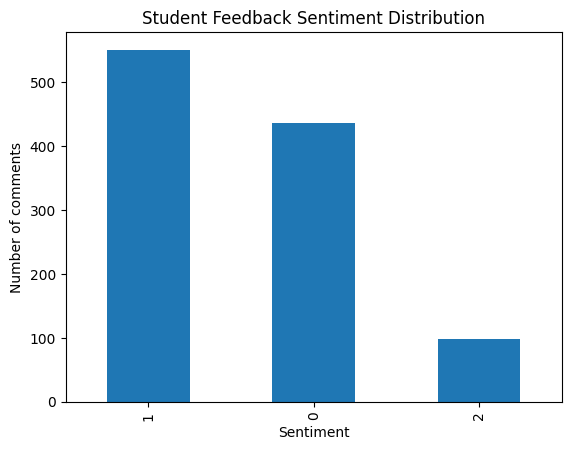

In [54]:
import matplotlib.pyplot as plt

df["sentiments"].value_counts().plot(kind="bar")

plt.xlabel("Sentiment")
plt.ylabel("Number of comments")
plt.title("Student Feedback Sentiment Distribution")

plt.show()

In [55]:
from collections import Counter

words = " ".join(df["comments"]).lower().split()

word_counts = Counter(words)

word_counts.most_common(10)

[('the', 266),
 ('is', 197),
 ('you', 197),
 ('to', 181),
 ('teachers', 179),
 ('not', 169),
 ('and', 164),
 ('in', 163),
 ('are', 156),
 ('of', 148)]